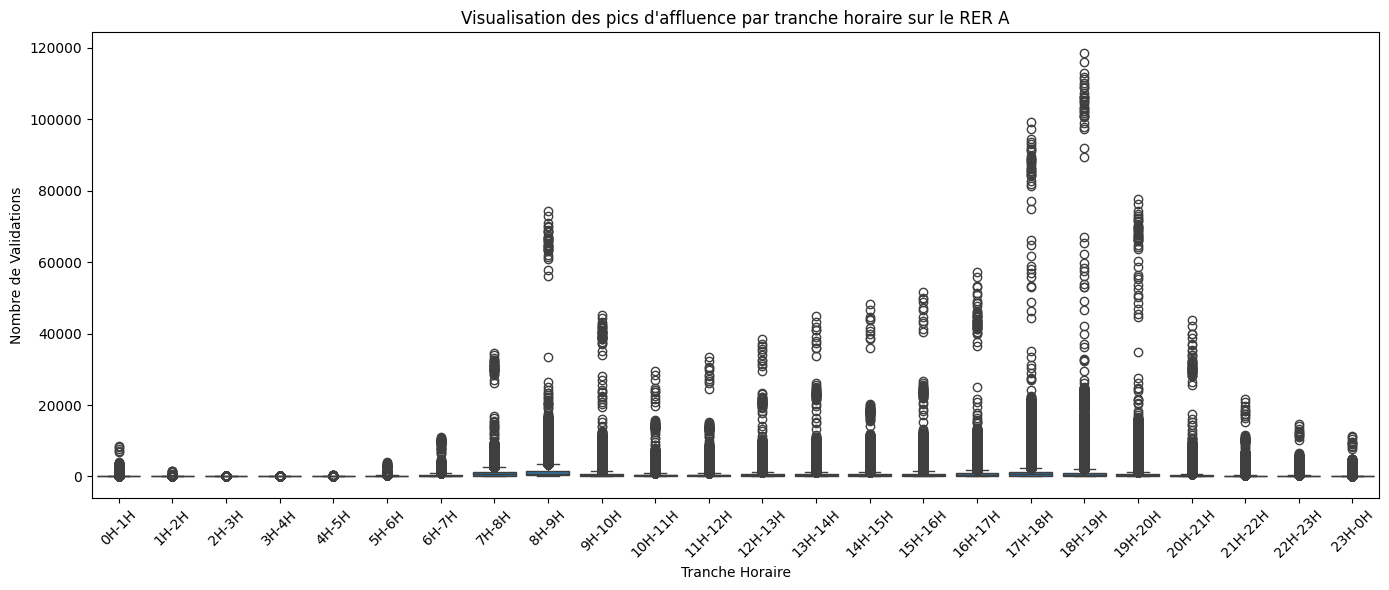

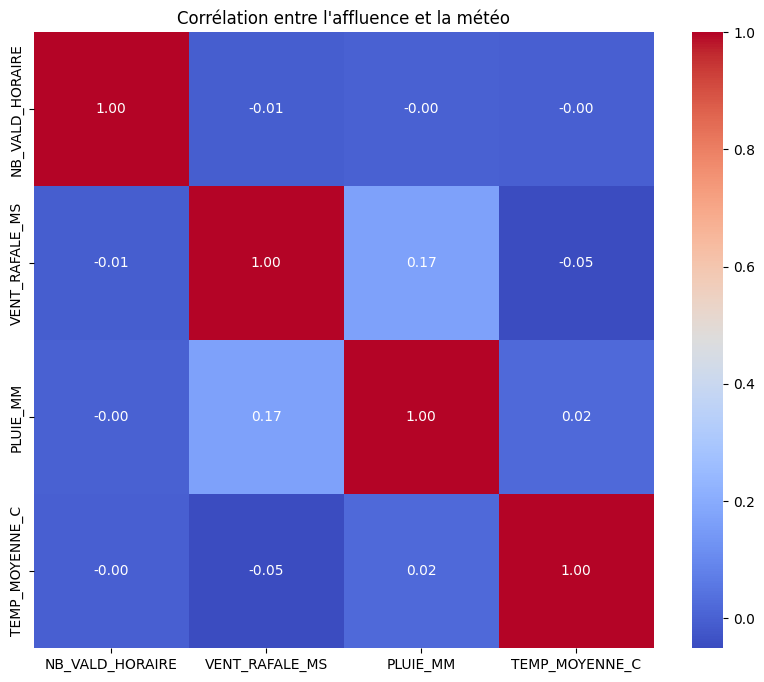

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du fichier parquet
df = pd.read_parquet('RER_A_Final_FINAL.parquet')

# On extrait le premier chiffre de 'TRNC_HORR_60' pour trier proprement le graphique
df['heure_tri'] = df['TRNC_HORR_60'].str.split('H').str[0].astype(int)
df = df.sort_values('heure_tri')

# --- Graphique 1 : Boxplot de l'affluence par heure ---
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='TRNC_HORR_60', y='NB_VALD_HORAIRE')
plt.xticks(rotation=45)
plt.title("Visualisation des pics d'affluence par tranche horaire sur le RER A")
plt.xlabel("Tranche Horaire")
plt.ylabel("Nombre de Validations")
plt.tight_layout()
plt.show()

# --- Graphique 2 : Matrice de corrélation (uniquement sur les colonnes numériques) ---
plt.figure(figsize=(10, 8))
# On sélectionne les colonnes météo numériques et l'affluence
colonnes_numeriques = ['NB_VALD_HORAIRE', 'VENT_RAFALE_MS', 'PLUIE_MM', 'TEMP_MOYENNE_C']
sns.heatmap(df[colonnes_numeriques].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Corrélation entre l'affluence et la météo")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import joblib


# On affiche la taille réelle
print(f"Taille originale du jeu de données : {len(df)} lignes")

# On tire au sort 100 000 lignes
df_sample = df.sample(n=100000, random_state=42)

# 1. Sélection des colonnes utiles SUR L'ÉCHANTILLON
features = ['TRNC_HORR_60', 'CAT_JOUR', 'LIBELLE_ARRET', 'METEO_GLOBALE', 'VENT_RAFALE_MS', 'PLUIE_MM', 'TEMP_MOYENNE_C']
X = df_sample[features]
y = df_sample['NB_VALD_HORAIRE']

# 2. Encodage (One-Hot)
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Séparation Entraînement / Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

#   NORMALISATION DES DONNÉES
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # On applique la même règle sur les données de test

# 4. Initialisation des modèles (avec early_stopping pour l'IA)
models = {
    "Régression Linéaire": LinearRegression(),
    "Arbre de Décision": DecisionTreeRegressor(random_state=42),
    # L'ajout de early_stopping=True empêche l'algorithme de tourner à l'infini
    "Réseau de Neurones (MLP)": MLPRegressor(max_iter=300, early_stopping=True, random_state=42)
}

# 5. Entraînement et Validation Croisée (sur les données normalisées !)
best_score = -float('inf')
best_model = None
best_model_name = ""

print("--- Évaluation des modèles (Validation Croisée R²) ---")
for name, model in models.items():
    print(f"Entraînement en cours pour : {name}...")
    # On utilise bien X_train_scaled ici ! On descend cv à 3 pour aller plus vite.
    scores = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='r2')
    mean_score = scores.mean()
    print(f"{name} : Score R² moyen = {mean_score:.4f}\n")

    if mean_score > best_score:
        best_score = mean_score
        best_model = model
        best_model_name = name

# 6. Entraînement final du meilleur modèle
print(f"Entraînement final du meilleur modèle : {best_model_name}")
best_model.fit(X_train_scaled, y_train)

# 7. Sauvegarde du modèle ET du scaler
joblib.dump(best_model, 'meilleur_modele_rera.pkl')
joblib.dump(scaler, 'scaler_rera.pkl') # Très important pour le Dashboard !
print("Félicitations ! Modèle et Scaler sauvegardés !")

Taille originale du jeu de données : 1219608 lignes
--- Évaluation des modèles (Validation Croisée R²) ---
Entraînement en cours pour : Régression Linéaire...
Régression Linéaire : Score R² moyen = 0.3274

Entraînement en cours pour : Arbre de Décision...
Arbre de Décision : Score R² moyen = 0.2854

Entraînement en cours pour : Réseau de Neurones (MLP)...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Réseau de Neurones (MLP) : Score R² moyen = 0.5449

Entraînement final du meilleur modèle : Réseau de Neurones (MLP)
Félicitations ! Modèle et Scaler sauvegardés !


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
!pip show numpy scikit-learn

Name: numpy
Version: 2.0.2
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2024, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
       notice, this list of conditions and the following disclaimer.

    * Redistributions in binary form must reproduce the above
       copyright notice, this list of conditions and the following
       disclaimer in the documentation and/or other materials provided
       with the distribution.

    * Neither the name of the NumPy Developers nor the names of any
       contributors may be used to endorse or promote products derived
       from this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRI